# TRAINING of Hyperparameters 3step_NN

In [1]:
#########################     LIBRARIES     ##########################
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam,Nadam,Adamax
from ann_functions import getModel, kCrossVal, transfBestparam
from time import perf_counter
import pandas

seed = 7
np.random.seed(seed)

c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
########################     PREPARATION      ##########################
HF_data = np.loadtxt("../DATA_shear_cube/Data_Train_bases_young/HF_num_data.txt").astype(int) #list of number of HF data
Nlf_models = np.loadtxt("../DATA_shear_cube/Data_Train_bases_young/N_bases.txt").astype(int)   #list of number of bases
HF_data_str = [str(num) for num in HF_data]
U_lf_train_full = np.loadtxt("../DATA_shear_cube/Data_Train_bases_young/Ulf_train_young.txt")

n_bases = U_lf_train_full.shape[1]   
m = list(Nlf_models).index(n_bases)
n_HF = 15
n_HF_txt = str(n_HF) + '.txt'

In [4]:
#########################     TRAIN SET      ##########################
mu_train_LF = np.loadtxt("../DATA_shear_cube/Data_Train_bases_young/mu_train_LF_young.txt")[:,0]
Nlf = np.size(mu_train_LF)  #number of low-fidelity data to TRAIN the NN

U_lf_train = U_lf_train_full[:,m]

mu_train_HF = np.loadtxt("../DATA_shear_cube/Data_Train_bases_young/mu_train_HF_young_" + n_HF_txt)[:,0]
Nhf = np.size(mu_train_HF)  # number of high-fidelity data to TRAIN the NN

U_hf_train = np.loadtxt("../DATA_shear_cube/Data_Train_bases_young/Uhf_train_young_" + n_HF_txt)

NepoLF = 3000                          # number of epochs for first NN: NN_LF
NepoLin = 1500                         # number of epochs for second NN: NN_Lin
NepoHF = 2000                          # number of epochs for second NN: NN_HF


In [5]:
#########################     TEST SET      ##########################
mu_test = np.loadtxt("../DATA_shear_cube/Data_Test_bases_young/mu_test_young.txt")[:,0]
N_test = np.size(mu_test)

U_lf_test_full = np.loadtxt("../DATA_shear_cube/Data_Test_bases_young/Ulf_test_young.txt")
U_lf_test = U_lf_test_full[:,m]

U_hf_test = np.loadtxt("../DATA_shear_cube/Data_Test_bases_young/Uhf_test_young.txt")

In [6]:
########################     NORMALIZATION  #########################
#Input
mu_max = np.max(mu_test)
mu_min = np.min(mu_test)

mu_test_norm = (mu_test - mu_min) / (mu_max - mu_min)
mu_train_LF_norm = (mu_train_LF - mu_min) / (mu_max - mu_min)
mu_train_HF_norm = (mu_train_HF - mu_min) / (mu_max - mu_min)

#Output
# TRANSFORMATION     # 
# in order to reduce the linear relationship between the Young modulus and the displacement
U_lf_train = np.exp(U_lf_train*100)*1e-6
U_lf_test = np.exp(U_lf_test*100)*1e-6
U_hf_train = np.exp(U_hf_train*100)*1e-6
U_hf_test = np.exp(U_hf_test*100)*1e-6
#
lfmean = np.mean(U_lf_test)
hfmean = np.mean(U_hf_test)

U_lf_train = U_lf_train - lfmean
U_lf_test = U_lf_test - lfmean
U_hf_train = U_hf_train - hfmean
U_hf_test = U_hf_test - hfmean

# NN_{LF}: used as Neural Network single fidelity

In [7]:
##########################       FIRST NN: NN_LF     ##########################
K.clear_session()
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'} # where do they come from 

modelLF = getModel(bestLF_params,'LF')
histLF = modelLF.fit(mu_train_LF_norm, U_lf_train ,epochs=NepoLF,batch_size=Nlf, verbose = 0)
print('LF NN done')

ULF = modelLF.predict(mu_test_norm)
print('\nLF Model:')

test_mse = np.mean(np.square(U_lf_test - ULF[:,0]))
print(f"Test MSE: {test_mse}")

r_2 = 1 - np.sum(np.square(U_lf_test - ULF[:,0])) / np.sum(np.square(U_lf_test - np.mean(U_lf_test)))
print(f"R^2: {r_2}")

LF NN done
4/4 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 2.1879775408990998e-09
R^2: 0.9999338724566875


4/4 [==============================] - 0s 3ms/step


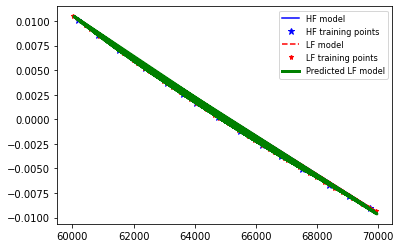


-------  #HF data = 15  -------


In [8]:
##################     Print LF, HF and LF-predicted models      ###################
plt.figure()
plt.plot(mu_test, U_hf_test, 'b-', linewidth = 1.5, label = 'HF model')
plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
plt.plot(mu_test, U_lf_test,'r--', linewidth = 1.5, label = 'LF model')
plt.plot(mu_train_LF, U_lf_train,'r*', markersize = 5, label = 'LF training points')
plt.plot(mu_test, modelLF.predict(mu_test_norm), linewidth = 3, color = 'green', label = 'Predicted LF model')
plt.legend(prop={'size': 8.3})
plt.show()



print(f"\n-------  #HF data = {n_HF}  -------")
start = perf_counter()


# NN_{lin}

In [9]:
##########################    SECOND NN: NN_Lin    ##########################
mu_test_help = modelLF.predict(mu_test_norm)[:,0]
mu_test_in = np.vstack((mu_test_norm,mu_test_help)).transpose() # <- TEST INPUT for the second NN: NN_HF

mu_train_help = modelLF.predict(mu_train_HF_norm)[:,0] #f_LF(mu_hf_train)
mu_lin = np.vstack((mu_train_HF_norm ,mu_train_help)).transpose() # <- TRAINING INPUT for the second NN: NN_HF

bestLin_params = {'lr' : 0.001, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam', 'l2weight' : 0.01}
modelLin = getModel(bestLin_params,'Hflin')
histLin = modelLin.fit(mu_lin, U_hf_train, validation_data=(mu_test_in, U_hf_test), epochs=NepoLin,batch_size=Nhf,verbose=0, validation_freq = 50)

ULin = modelLin.predict(np.vstack((mu_test_norm,mu_test_help)).transpose())


4/4 [==============================] - 0s 9ms/step


# NN_{HF}

In [10]:
##########################    THIRD NN: NN_HF    ##########################
#Input for training NN_HF
mu_help1 = modelLin.predict(mu_lin)[:,0]
mu_final = np.vstack((mu_train_HF_norm ,mu_train_help, mu_help1)).transpose()

#Input for testing NN_HF
mu_test_help1 = modelLin.predict(mu_test_in)[:,0]
mu_test_final = np.vstack((mu_test_norm, mu_test_help, mu_test_help1)).transpose()

name = '3step'

4/4 [==============================] - 0s 2ms/step


In [11]:
####################    HYPERPARAMETER OPTIMIZATION    #######################
MAX_EVAL = 15

K.clear_session()
bayes_trials = Trials()
opt_list = ['Adam','Adamax']
kernel_list = ['uniform','glorot_uniform']
aux_dic = {'opt': opt_list, 'kernel_init': kernel_list}
space = {
    'nodes' : hp.qloguniform('nodes',np.log(4),np.log(64),2),
     'l2weight' : hp.loguniform('l2weight',np.log(0.0001),np.log(100)),
     'lr': hp.loguniform('lr',np.log(0.0001),np.log(0.1)),
     'kernel_init': hp.choice('kernel_init',kernel_list),
     'opt' : hp.choice('opt',opt_list)}

def objective(params):
    K.clear_session()
    CVres = kCrossVal(Nhf,NepoHF,mu_final, U_hf_train,params,name)
    return {'loss' : CVres, 'params':params, 'status': STATUS_OK}

#The following call will optimize and select the best parameters:
best_params = fmin(fn = objective,
                   space = space,
                   algo = tpe.suggest,
                   max_evals = MAX_EVAL,
                   trials = bayes_trials)

transfBestparam(best_params,aux_dic)
print(best_params)


1/1 [==============================] - 0s 73ms/step  

1/1 [==============================] - 0s 28ms/step  

1/1 [==============================] - 0s 31ms/step  

1/1 [==============================] - 0s 29ms/step  

1/1 [==============================] - 0s 29ms/step  

1/1 [==============================] - 0s 29ms/step  

1/1 [==============================] - 0s 34ms/step  

1/1 [==============================] - 0s 31ms/step  

1/1 [==============================] - 0s 30ms/step  

1/1 [==============================] - 0s 29ms/step  

1/1 [==============================] - 0s 30ms/step  

1/1 [==============================] - 0s 30ms/step  

1/1 [==============================] - 0s 28ms/step  

1/1 [==============================] - 0s 55ms/step  

1/1 [==============================] - 0s 29ms/step  

1/1 [==============================] - 0s 69ms/step                                

1/1 [==============================] - 0s 30ms/step                                

1/1 [

KeyboardInterrupt: 

In [ ]:
####################    NN_HF training and PREDICTION    #######################
finalModel = getModel(best_params,name)
hist = finalModel.fit(mu_final, U_hf_train, validation_data=(mu_test_final,U_hf_test),epochs=NepoHF,batch_size=Nhf,verbose=0, validation_freq = 20)

UHF = finalModel.predict(mu_test_final)

stop = perf_counter()
elapsed = stop - start
print('Elapsed time: ', elapsed)
print('\nHF Model:')

test_mse = np.mean(np.square(U_hf_test - UHF[:,0]))
print(f"Test MSE: {test_mse}")

r2_HF = 1 - np.sum(np.square(U_hf_test - UHF[:,0])) / np.sum(np.square(U_hf_test - np.mean(U_hf_test)))
print(f"R^2: {r2_HF}")

print('Number of base functions: ', int(Nlf_models[m]))
print('Number of HF data: ', n_HF)

U_Lin = modelLin.predict(np.vstack((mu_test_norm,mu_test_help)).transpose())


In [ ]:
####################    HF GRAPHS    #######################
plt.figure()
plt.plot(mu_test, UHF,'k', label = 'estimated $U_{HF}$ by $NN_{HF}$', linewidth = 3)
plt.plot(mu_test, U_Lin,'g', label = 'estimated $U_HF$ by $NN_{LIN}$')
plt.plot(mu_test, modelLF.predict(mu_test_norm), label = 'estimated $U_{LF}$ by $NN_{LF}$')
plt.plot(mu_train_HF, U_hf_train,'ro', label = 'HF data')
plt.plot(mu_test, U_hf_test,'--k', label = 'exact solution')
plt.title('High fidelity model ')
plt.legend(prop={'size': 8})

In [ ]:
####################    TRAINING INSIGHTS    #######################
plt.figure()
plt.subplot(2,1,1)
plt.plot(hist.history['mse'],color='red',label='High fidelity train mse')
plt.plot(histLin.history['mse'],color='green',label='high fidelity lin')
plt.plot(histLF.history['mse'],color='black',label='Low fidelity')
plt.legend()
plt.yscale('log')
plt.subplot(2,1,2)
plt.plot(hist.history['val_mse'],color='red')
plt.plot(histLin.history['val_mse'],color='green')
plt.yscale('log')
